In [83]:
from upconversion_models import AndersonModel, AndersonModelUnfolded
from upconversion_models.jablonski_patch import (
    EmissionTransform,
    Simulator,
    LineEnergyPost,
    SteadyState,
)
from upconversion_models.utils import h, c, k
from poincare import solvers
from pint import get_application_registry
import numpy as np
import matplotlib.pyplot as plt

u = get_application_registry()

Upconversion model with the 6th level unfolded into 6s (~540 nm) and 6h (~520 nm).

In [84]:
sim = (
    Simulator(AndersonModelUnfolded())
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-10))
    .with_values({AndersonModel.energy_flux: 5 * u.W / u.cm**2})
    .with_post(LineEnergyPost())
    .with_transform(EmissionTransform(kind="emission"), append=True)
)

### Poblation balance
At every point in time, we can define 

$$
n_s(t) + n_h(t) = n_6(t) 
$$

Here, the phonon assisted transition and relaxation rates $k_{up}$ and $k_{down}$ between $n_s$ and $n_h$ ocurr much faster than all other processes. Because of that the poblation stays constant in time

$$
\frac{n_h}{n_s} = \frac{k_{up}}{k_{down}} = C
$$


With that, we can define $f_s$ and $f_h = 1-f_s$, the fraction of the total $n_6$ poblation that are in $n_s$ and $n_h$ respectevely.


$$
n_s(t)  = f_s \ n_6(t), \ \ \ n_h(t) =  f_h n_6(t), \ \ \ \frac{n_h(t)}{n_s(t)} = \frac{1-f_s}{f_s}
$$

More importantly, we can control the poblation ratios through the intra-level rates. For that we set $k_{up}$ and $k_{down}$ very fast while keeping $$\frac{k_{up}}{k_{down}} =  \frac{1-f_s}{f_s}$$


/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/matplotlib/cbook.py:1407: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asanyarray(x, float)


<xarray.Dataset> Size: 13kB
Dimensions:      (T: 50)
Coordinates:
  * T            (T) float64 400B 160.0 163.3 166.5 169.8 ... 313.5 316.7 320.0
Data variables: (12/31)
    line_rad     (T) float64 400B 0.01688 0.01683 0.01678 ... 0.01435 0.01429
    line_rad81   (T) float64 400B 0.0003685 0.000362 ... 4.782e-05 4.501e-05
    line_rad82   (T) float64 400B 0.0003869 0.0003801 ... 5.021e-05 4.726e-05
    line_rad83   (T) float64 400B 0.000129 0.0001267 ... 1.674e-05 1.575e-05
    line_rad85   (T) float64 400B 3.685e-05 3.62e-05 ... 4.782e-06 4.501e-06
    line_rad6h1  (T) float64 400B 3.445e-05 3.813e-05 ... 0.000411 0.0004198
    ...           ...
    Er8          (T) float64 400B 3.954e-07 3.884e-07 ... 5.13e-08 4.829e-08
    Er9          (T) float64 400B 2.504e-09 2.497e-09 ... 1.497e-09 1.466e-09
    Yb1          (T) float64 400B 0.171 0.171 0.171 0.171 ... 0.171 0.171 0.171
    Yb2          (T) float64 400B 4.295e-05 4.283e-05 ... 3.651e-05 3.637e-05
    time         (T) float64 400B 0.8426 0.3315 0.9141 ... 0.1299 0.1793 0.1586
    event        (T) int64 400B 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
Attributes: (12/17)
    line_rad:     2.026174774291907e-21 joule * meter / centimeter
    line_rad81:   4.866792350014875e-21 joule * meter / centimeter
    line_rad82:   3.575602542868071e-21 joule * meter / centimeter
    line_rad83:   2.8406175757229678e-21 joule * meter / centimeter
    line_rad85:   1.887123564291482e-21 joule * meter / centimeter
    line_rad6h1:  3.738491103154284e-21 joule * meter / centimeter
    ...           ...
    line_rad51:   2.979668785723393e-21 joule * meter / centimeter
    line_rad52:   1.6884789785765893e-21 joule * meter / centimeter
    line_rad53:   9.534940114314858e-22 joule * meter / centimeter
    line_rad31:   2.026174774291907e-21 joule * meter / centimeter
    line_rad32:   7.349849671451036e-22 joule * meter / centimeter
    line_rad2:    1.2911898071468036e-21 joule * meter / centimeter

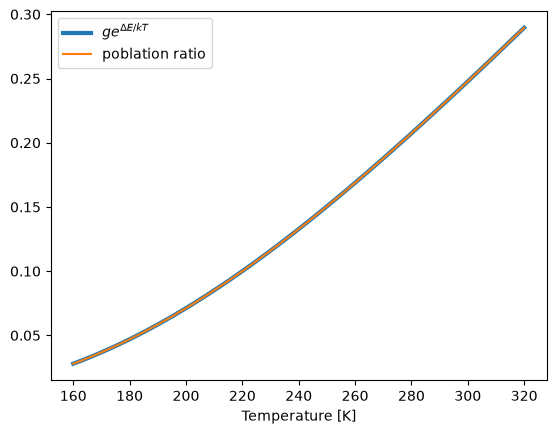

In [85]:

Ts = np.linspace(160, 320) * u.K

ds = SteadyState().sweep(
    sim,
    variable=AndersonModelUnfolded.T,
    values=Ts,
)

df = ds.to_dataframe()
df["poblation_ratio"] = df["Er6h"] / df["Er6s"]

dE = (AndersonModelUnfolded.Er6h.energy - AndersonModelUnfolded.Er6s.energy)  # or read the defaults

def F(T): return  3 * np.exp(-1 * dE / (k * T))


plt.plot(Ts, F(Ts), label=r"$g e^{\Delta E / kT}$", lw=3)
plt.plot(Ts, df["poblation_ratio"], label="poblation ratio")

plt.xlabel("Temperature [K]")
plt.legend()

ds

In [86]:
x = (1 / Ts).to(1 / u.K).magnitude
y = np.log(df["poblation_ratio"].to_numpy())
slope, intercept = np.polyfit(x, y, 1)

dE_eff = (-slope * u.K * k / (h * c)).to(1 / u.cm)
g_eff = np.exp(intercept)
print(dE_eff, g_eff)  


519.9910497123112 / centimeter 2.999878024554656


### Anderson and Yu's compatibility

To recover Anderson's model at room temperature $T_0$, the transitions previously made by the old n_6 should be the same as the ones made by the new $n_s$ and $n_h$ combined.

$$
k^X_{6} \ n_6(T_0)= k^X_s \ n_s(T_0) + k^X_h \ n_h(T_0)
$$

where $X = r, nr, ET$

>To ensure that new total poblation $n_6(T_0)$ stays the same as the old $n_{6}$, the other constants must stay the same, keeping the energy flow outside the unfolded levels the same.

Using 

$$n_s(T) = f_s(T) \ n_6$$
$$n_h(T) = (1-f_s(T)) \ n_6$$

we get the relationship

$$
k^X_6 = k^X_6s \ f_s(T_0) + k^X_6h \ (1 - f_s(T_0))
$$

for the radiative part in particular

$$
k^{rad}_6 = k^{rad}_s \ f_s(T_0) + k^{rad}_h \ (1 - f_s(T_0))
$$


From Yu's experimental result (2014, Fig 5c)

$$
\frac{I_{H}}{I_{S}} =
 \frac{\omega_h k^{rad}_h n_h}{\omega_s k^{rad}_s n_s}  = 4.58 \ \exp{(-745/T)} = G(T)
$$

using $\frac{n_h}{n_s} = F(T)$, we get the next constraint at $T_0$

$$
0 = k^{rad}_s \ \omega_s \ G(T_0) - k^{rad}_h \ \omega_h \ F(T_0)
$$

In [87]:
T0 = AndersonModelUnfolded.T0.default

fs0 = 1 / (1 + F(T0))  # fs at T0


def G(T):
    # Yu's experimental result
    return 4.58 * np.exp(-745 * u.K / T)


ws = 1 / 541  # proportional to ws
wh = 1 / 525  # proportional to wh

kr_6 = 1_510  # from Anderson's
M = np.array(
    [
        [fs0, 1 - fs0],
        [ws * G(T0), -wh * F(T0)],
    ]
)

b = np.array([kr_6, 0])

ks, kh = np.linalg.solve(M, b)
ks, kh, fs0

(np.float64(1374.31058766948),
 np.float64(2057.649877758112),
 <Quantity(0.801431859, 'dimensionless')>)

Constrained unfolded model initialization

In [88]:
sim = (
    Simulator(AndersonModelUnfolded())
    .with_transform(EmissionTransform(kind="emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-10, atol=1e-10))
    .with_values(
        {
            AndersonModelUnfolded.k_r6s: ks / u.s,
            AndersonModelUnfolded.k_r6h: kh / u.s,
        }
    )
    .with_post(LineEnergyPost())
)

Anderson's model for cross-checking

In [89]:
sim_and = (
    Simulator(AndersonModel())
    .with_transform(EmissionTransform(kind="emission"), append=True)
    .with_solver(solvers.LSODA(rtol=1e-9, atol=1e-9))
    .with_post(LineEnergyPost())
)

### Time resolved simulation against Anderson2013

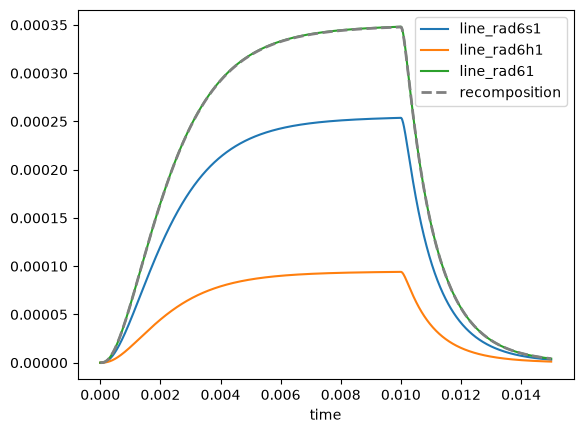

In [90]:
from upconversion_models.jablonski_patch import PulsedExcitation
import numpy as np

pulse = PulsedExcitation(
    pulse_width=10e-3 * u.s,
    pulse_height=2 * u.W / u.cm**2,
    pump="energy_flux",
)

save_at = np.linspace(0, 15e-3, 1000) * u.s
df = (
    pulse.solve(sim, save_at=save_at)
    .pint.dequantify()
    .to_dataframe()[["line_rad6s1", "line_rad6h1"]]
)

df = df.join(
    pulse.solve(sim_and, save_at=save_at)
    .pint.dequantify()
    .to_dataframe()[["line_rad61"]]
)

df.plot()

df["recomposition"] = df["line_rad6s1"] + df["line_rad6h1"]

plt.plot(df["recomposition"], lw=2, ls="--", color="gray", label="recomposition")
plt.legend()

### Temperature sweep comparing Yu2014

In [91]:
Ts = (
    np.concatenate([np.linspace(70, T0.magnitude, 10)[:-1], np.linspace(T0.magnitude, 600, 10)])
    * u.K
)

ds = SteadyState().sweep(
    sim.with_values({AndersonModelUnfolded.energy_flux: 5 * u.W / u.cm**2}),    
    variable=AndersonModelUnfolded.T,
    values=Ts,
)

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/matplotlib/cbook.py:1407: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asanyarray(x, float)


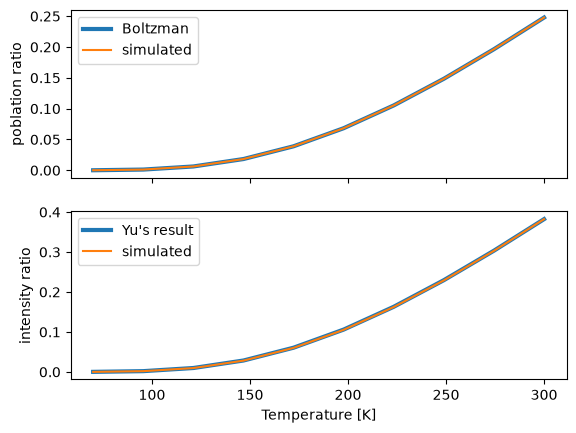

In [92]:
fig, axs = plt.subplots(2, sharex=True)

filt = Ts < 320 * u.K
df = ds.to_dataframe()
axs[0].plot(Ts[filt], F(Ts[filt]), label=r"Boltzman", lw=3)
axs[0].plot(Ts[filt], (df["Er6h"] / df["Er6s"])[filt], label="simulated")
axs[0].set_ylabel("poblation ratio")
axs[0].legend()

axs[1].plot(Ts[filt], G(Ts[filt]), lw=3, label="Yu's result")
axs[1].plot(Ts[filt], (df["Er6h"] * wh * kh / df["Er6s"] / ws / ks)[filt], label="simulated")
axs[1].set_ylabel("intensity ratio")
axs[1].set_xlabel("Temperature [K]")
axs[1].legend()

### Non trivial temperature dependance

This constrained unfolded model shows (for some configuration of free parameters) the influence of temperature on other parts of the spectrum as presented by Tong2015.

Text(0.5, 0, 'Temperature [K]')

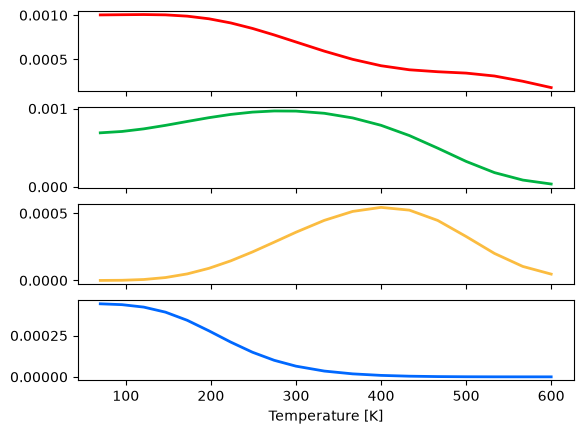

In [93]:
fig, axs = plt.subplots(4, sharex=True)
axs[0].plot(Ts, df["line_rad51"], label="655 nm", lw=2,  c="#ff0000")
axs[1].plot(Ts, df["line_rad6s1"], label="541 nm", lw=2, c="#00b342")
axs[2].plot(Ts, df["line_rad6h1"], label="520 nm", lw=2, c="#fbbc40")
axs[3].plot(Ts, df["line_rad81"], label="410 nm", lw=2,  c="#0068ff")
plt.xlabel("Temperature [K]")

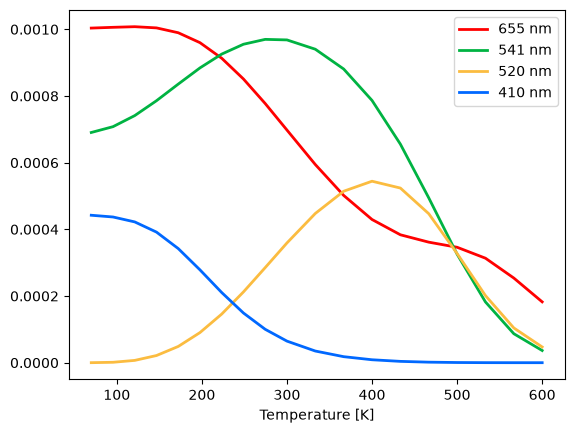

In [94]:
plt.plot(Ts, df["line_rad51"], label="655 nm", lw=2, c="#ff0000")
plt.plot(Ts, df["line_rad6s1"], label="541 nm", lw=2, c="#00b342")
plt.plot(Ts, df["line_rad6h1"], label="520 nm", lw=2, c="#fbbc40")
plt.plot(Ts, df["line_rad81"], label="410 nm", lw=2, c="#0068ff")
plt.xlabel("Temperature [K]")
plt.legend()

In [95]:
import xarray as xr
phonons = np.linspace(100, 600, 10) / u.cm

ds_ph = xr.concat(
    [
        SteadyState().sweep(
            sim.with_values(
                {
                    AndersonModelUnfolded.energy_flux:200 * u.W / u.cm**2,
                    AndersonModelUnfolded.phonon_wavenumber: ph,
                }
            ),
            variable=AndersonModelUnfolded.T,
            values=Ts,
        )
        for ph in phonons
    ],
    dim=xr.DataArray(phonons.magnitude, dims="phonon", name="phonon"),
)

/Users/ramirohar/Documents/tesis/upconversion_models/.pixi/envs/default/lib/python3.13/site-packages/matplotlib/cbook.py:1407: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  return np.asanyarray(x, float)


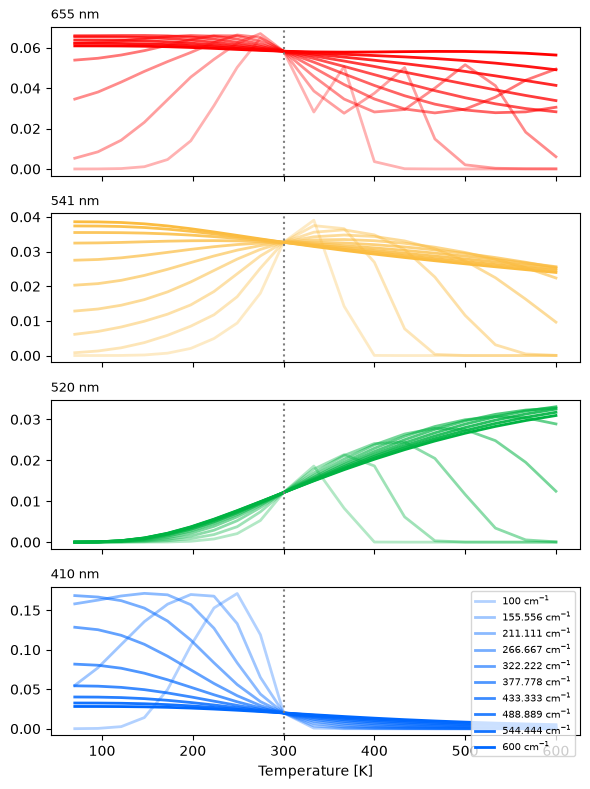

In [96]:
lines = [
    ("line_rad51", "655 nm", "#ff0000"),
    ("line_rad6s1", "541 nm", "#fbbc40"),
    ("line_rad6h1", "520 nm", "#00b342"),
    ("line_rad81", "410 nm", "#0068ff"),
]
shades = np.linspace(0.3, 1, len(phonons))

fig, axs = plt.subplots(len(lines), sharex=True, figsize=(6, 8))
for ax, (line, label, color) in zip(axs, lines):
    for ph, alpha in zip(ds_ph.phonon.values, shades):
        ax.plot(Ts, ds_ph[line].sel(phonon=ph), c=color, alpha=alpha, lw=2, label=f"{ph:g} cm$^{{-1}}$")
    ax.axvline(T0.magnitude, color="gray", ls=":")
    ax.set_title(label, loc="left", fontsize=9)
axs[-1].legend(fontsize=7)
axs[-1].set_xlabel("Temperature [K]")
fig.tight_layout()